In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.geoaxes import GeoAxes
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import numpy as np
import xarray as xr
import xesmf as xe
from pyproj import Transformer
import matplotlib
import matplotlib.pyplot as plt


In [3]:
from xmip.preprocessing import combined_preprocessing
import regionmask
from xmip.regionmask import merged_mask
import warnings
import matplotlib.pyplot as plt
import numpy as np
import glob
import xarray as xr
import xbudget
import regionate
import xwmt
import xwmb
import xgcm
import matplotlib.colors as mcolors
import cmocean
import cartopy.crs as ccrs
from scipy.interpolate import PchipInterpolator
# import CM4Xutils #needed to run pip install nc-time-axis
# from regionate import MaskRegions, GriddedRegion
import sys
sys.path.insert(0, '/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/src')
from src import *
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 150

### Request HPC Resources

In [4]:
from dask_jobqueue import SLURMCluster  # setup dask cluster 
from dask.distributed import Client

log_directory="/vortexfs1/home/anthony.meza/scratch/CM4X/CM4XTransientTracers/WaterMassBudgets/logs"

cluster = SLURMCluster(
    cores=36,
    processes=1,
    memory='190GB',
    walltime='03:00:00',
    queue='compute',
    interface='ib0', 
log_directory = log_directory)
print(cluster.job_script())
cluster.scale(jobs=16)

client = Client(cluster)
client

#!/usr/bin/env bash

#SBATCH -J dask-worker
#SBATCH -e /vortexfs1/home/anthony.meza/scratch/CM4X/CM4XTransientTracers/WaterMassBudgets/logs/dask-worker-%J.err
#SBATCH -o /vortexfs1/home/anthony.meza/scratch/CM4X/CM4XTransientTracers/WaterMassBudgets/logs/dask-worker-%J.out
#SBATCH -p compute
#SBATCH -n 1
#SBATCH --cpus-per-task=36
#SBATCH --mem=177G
#SBATCH -t 03:00:00

/vortexfs1/home/anthony.meza/miniforge3/envs/cm4x_chapter2/bin/python -m distributed.cli.dask_worker tcp://172.16.3.59:45304 --name dummy-name --nthreads 36 --memory-limit 176.95GiB --nanny --death-timeout 60 --interface ib0



Connection method: Cluster object,Cluster type: dask_jobqueue.SLURMCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://172.16.3.59:45304,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B


In [5]:
native_path = "/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/data/model/transient_tracers_z"
files = ["CM4Xp125_piControl_transient_tracers_z.zarr", "CM4Xp125_historical_transient_tracers_z.zarr", "CM4Xp125_ssp585_transient_tracers_z.zarr"]
full_depth_files = [native_path + "/" + a for a in files]

files = ["CM4Xp125_piControl_transient_tracers_surface.zarr", 
         "CM4Xp125_historical_transient_tracers_surface.zarr", 
         "CM4Xp125_ssp585_transient_tracers_surface.zarr"]
surface_files = [native_path + "/" + a for a in files]

In [6]:
def preprocess(ds):
    if ("year_ctrl" in ds.coords) or ("time_ctrl" in ds.coords):
        # if "time_ctrl" in ds.coords:
        #     ds = ds.reset_coords("year_ctrl", drop=True)
        # else:
        #     ds = ds.reset_coords("time_ctrl", drop=True)
        ds = ds.expand_dims(expt=["control"])
        ds.coords["year"] = ds.coords["year"]
        ds = ds.drop_vars(["year_ctrl"])
    else: 
        ds = ds.expand_dims(expt=["forced"])        
    return ds.isel(yh = slice(0, 120)).sel(year = slice(None, 2099))
ds_ctrl= xr.open_mfdataset(full_depth_files[0], combine="nested", concat_dim=["year"], parallel=True, preprocess=preprocess, engine = "zarr")
ds_forced = xr.open_mfdataset(full_depth_files[1:], combine="nested", concat_dim=["year"], parallel=True, preprocess=preprocess, engine = "zarr")

ds= xr.concat([ds_ctrl, ds_forced], dim = "expt").drop_vars(["lat", "lon"])

In [7]:
def _project_lonlat(lon2d, lat2d, crs_out):
    tf = Transformer.from_crs("EPSG:4326", crs_out, always_xy=True)
    x, y = tf.transform(np.asarray(lon2d), np.asarray(lat2d))
    return x, y


def _polyline_arclen(v):
    dv = np.diff(v, axis=0)
    return np.sum(np.sqrt((dv**2).sum(axis=1)))


def largest_isobath_contour(ds, H, crs="EPSG:3031", bbox_lonlat=None):
    lon2d = ds["geolon"]
    lat2d = ds["geolat"]
    deptho = ds["deptho"].fillna(0.0)

    x2d, y2d = _project_lonlat(lon2d, lat2d, crs_out=crs)

    fig, ax = plt.subplots()
    cs = ax.contour(x2d, y2d, np.asarray(deptho), levels=[H])
    segs = cs.allsegs[0]
    plt.close(fig)

    if len(segs) == 0:
        raise ValueError(f"No contour found for depth={H}.")

    lens = np.array([_polyline_arclen(v) for v in segs])
    poly_xy = segs[int(np.argmax(lens))]

    tf_inv = Transformer.from_crs(crs, "EPSG:4326", always_xy=True)
    lonp, latp = tf_inv.transform(poly_xy[:, 0], poly_xy[:, 1])
    lonp = np.asarray(lonp)
    latp = np.asarray(latp)

    if bbox_lonlat is not None:
        lonmin, lonmax, latmin, latmax = bbox_lonlat
        m = (lonp >= lonmin) & (lonp <= lonmax) & (latp >= latmin) & (latp <= latmax)
        if m.sum() < 2:
            raise ValueError("bbox_lonlat removed (almost) all contour points.")
        poly_xy = poly_xy[m]
        lonp = lonp[m]
        latp = latp[m]

    return poly_xy, poly_xy[:, 0].copy(), poly_xy[:, 1].copy(), lonp, latp

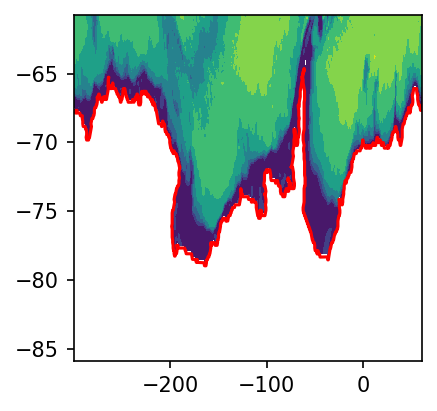

In [8]:
crs="EPSG:3031"
H = 0.0
_, _, _, poly_lon, poly_lat = largest_isobath_contour(ds, H, crs=crs)

poly_lon[poly_lon > 60] -= 360
fig, ax = plt.subplots(figsize = (3, 3))
ax.contourf(ds.geolon, ds.geolat, ds.deptho)
ax.plot(poly_lon, poly_lat, c = "r")

In [9]:
def _project_lonlat(lon2d, lat2d, crs_out):
    tf = Transformer.from_crs("EPSG:4326", crs_out, always_xy=True)
    x, y = tf.transform(np.asarray(lon2d), np.asarray(lat2d))
    return x, y


def _polyline_arclen(v):
    dv = np.diff(v, axis=0)
    return np.sum(np.sqrt((dv**2).sum(axis=1)))


def _longest_true_run(mask):
    m = np.asarray(mask, dtype=bool)
    if m.size == 0 or not m.any():
        return None
    idx = np.flatnonzero(m)
    splits = np.where(np.diff(idx) > 1)[0] + 1
    runs = np.split(idx, splits)
    lens = np.array([r.size for r in runs], dtype=int)
    return runs[int(np.argmax(lens))]


def largest_isobath_contour(ds, H, crs="EPSG:3031", bbox_lonlat=None):
    lon2d = ds["geolon"]
    lat2d = ds["geolat"]
    deptho = ds["deptho"].fillna(0.0)

    x2d, y2d = _project_lonlat(lon2d, lat2d, crs_out=crs)

    fig, ax = plt.subplots()
    cs = ax.contour(x2d, y2d, np.asarray(deptho), levels=[H])
    segs = cs.allsegs[0]
    plt.close(fig)

    if len(segs) == 0:
        raise ValueError(f"No contour found for depth={H}.")

    lens = np.array([_polyline_arclen(v) for v in segs])
    poly_xy = segs[int(np.argmax(lens))]

    tf_inv = Transformer.from_crs(crs, "EPSG:4326", always_xy=True)
    lonp, latp = tf_inv.transform(poly_xy[:, 0], poly_xy[:, 1])
    lonp = np.asarray(lonp)
    latp = np.asarray(latp)

    if bbox_lonlat is not None:
        lonmin, lonmax, latmin, latmax = bbox_lonlat
        m = (lonp >= lonmin) & (lonp <= lonmax) & (latp >= latmin) & (latp <= latmax)

        run = _longest_true_run(m)
        if run is None or run.size < 2:
            raise ValueError("bbox_lonlat removed (almost) all contour points.")
        poly_xy = poly_xy[run]
        lonp = lonp[run]
        latp = latp[run]

    return poly_xy, poly_xy[:, 0].copy(), poly_xy[:, 1].copy(), lonp, latp


In [10]:

def _resample_polyline_xy(xy, ds_m):
    xy = np.asarray(xy)
    seg = np.sqrt(np.sum(np.diff(xy, axis=0) ** 2, axis=1))
    s = np.concatenate([[0.0], np.cumsum(seg)])
    if s[-1] <= 0:
        return xy, s
    n = max(2, int(np.floor(s[-1] / ds_m)) + 1)
    si = np.linspace(0.0, s[-1], n)
    xi = np.interp(si, s, xy[:, 0])
    yi = np.interp(si, s, xy[:, 1])
    return np.c_[xi, yi], si


def _tangent_normal_xy(xy):
    dxy = np.gradient(np.asarray(xy), axis=0)
    t = dxy / np.maximum(np.linalg.norm(dxy, axis=1, keepdims=True), 1e-12)
    n = np.c_[-t[:, 1], t[:, 0]]
    return t, n

In [185]:
import numpy as np
import xarray as xr
import xesmf as xe
import pandas as pd
from pyproj import Transformer


def cross_slope_transects_xesmf(
    ds,
    var,  # str | list[str]
    H,
    r=np.arange(-50e3, 200e3 + 2e3, 2e3),
    ds_along=10e3,
    crs="EPSG:3031",
    bbox_lonlat=None,
    k_orient=2e3,  # kept for API compatibility; not used for orientation
    method="bilinear",
    reuse_weights=False,
    return_geom=True,
):
    vars = [var] if isinstance(var, (str, bytes)) else list(var)

    poly_xy, _, _, lonp, latp = largest_isobath_contour(ds, H, crs=crs, bbox_lonlat=bbox_lonlat)
    poly_r, s_m = _resample_polyline_xy(poly_xy, ds_along)
    _, n = _tangent_normal_xy(poly_r)

    x0, y0 = poly_r[:, 0], poly_r[:, 1]
    nx, ny = n[:, 0].copy(), n[:, 1].copy()

    R = np.asarray(r, dtype=float)
    tf_inv = Transformer.from_crs(crs, "EPSG:4326", always_xy=True)
    ds_in = xr.Dataset({"lon": ds["geolon"], "lat": ds["geolat"]})

    nsec, nr = x0.size, R.size

    def _make_lonlat(nx_, ny_):
        xt = x0[:, None] + nx_[:, None] * R[None, :]
        yt = y0[:, None] + ny_[:, None] * R[None, :]
        lon_t_, lat_t_ = tf_inv.transform(xt, yt)
        return np.asarray(lon_t_), np.asarray(lat_t_)

    # provisional transects
    lon_t, lat_t = _make_lonlat(nx, ny)

    # sample depth along provisional transects (nearest) and orient normals via xarray linear regression
    deptho_raw = ds["deptho"]
    ds_out_depth = xr.Dataset(
        {"lon": xr.DataArray(lon_t.ravel(), dims=("loc",)),
         "lat": xr.DataArray(lat_t.ravel(), dims=("loc",))}
    )
    Rdepth = xe.Regridder(
        ds_in,
        ds_out_depth,
        "nearest_s2d",
        locstream_out=True,
        reuse_weights=False,
        unmapped_to_nan=True,
    )
    dloc0 = Rdepth(deptho_raw).values.reshape(nsec, nr)

    depth_tran0 = xr.DataArray(
        dloc0,
        dims=("section", "r"),
        coords={"section": np.arange(nsec), "r": R},
    ).where(lambda x: x > 0)

    pf = depth_tran0.polyfit(dim="r", deg=1, skipna=True)
    coef = pf["polyfit_coefficients"]
    slope = coef.sel(degree=1) if 1 in coef["degree"].values else coef.isel(degree=0)

    flip = xr.where(slope < 0, -1.0, 1.0).values
    nx *= flip
    ny *= flip

    # final transects (after flip)
    lon_t, lat_t = _make_lonlat(nx, ny)

    # re-sample depth on FINAL transects and mask land points (break lines, avoid sampling artifacts)
    ds_out_depth = xr.Dataset(
        {"lon": xr.DataArray(lon_t.ravel(), dims=("loc",)),
         "lat": xr.DataArray(lat_t.ravel(), dims=("loc",))}
    )
    Rdepth = xe.Regridder(
        ds_in,
        ds_out_depth,
        "nearest_s2d",
        locstream_out=True,
        reuse_weights=False,
        unmapped_to_nan=True,
    )
    dloc = Rdepth(deptho_raw).values.reshape(nsec, nr)
    wet = np.isfinite(dloc) & (dloc > 0)
    lon_t = np.where(wet, lon_t, np.nan)
    lat_t = np.where(wet, lat_t, np.nan)

    # sample variables
    ds_out = xr.Dataset(
        {"lon": xr.DataArray(lon_t.ravel(), dims=("loc",)),
         "lat": xr.DataArray(lat_t.ravel(), dims=("loc",))}
    )
    Rv = xe.Regridder(
        ds_in,
        ds_out,
        method,
        locstream_out=True,
        reuse_weights=reuse_weights,
        unmapped_to_nan=True,
    )
    vloc = Rv(ds[vars].where(ds["deptho"] > 0))

    mi = pd.MultiIndex.from_product([np.arange(nsec), R], names=("section", "r"))
    vloc = vloc.assign_coords(loc=mi).unstack("loc").assign_coords(s_m=("section", np.asarray(s_m)))

    transects = vloc[vars[0]] if len(vars) == 1 else vloc
    transects = transects.where(transects["r"] >= 0.0)

    if not return_geom:
        return transects

    lon0, lat0 = tf_inv.transform(x0, y0)
    geom = xr.Dataset(
        data_vars=dict(
            lon=(("section", "r"), lon_t, {"long_name": "transect longitude", "units": "degrees_east"}),
            lat=(("section", "r"), lat_t, {"long_name": "transect latitude", "units": "degrees_north"}),

            lon0=(("section",), np.asarray(lon0), {"long_name": "anchor longitude (r=0 on isobath)", "units": "degrees_east"}),
            lat0=(("section",), np.asarray(lat0), {"long_name": "anchor latitude (r=0 on isobath)", "units": "degrees_north"}),

            s_m=(("section",), np.asarray(s_m), {"long_name": "along-isobath distance from contour start", "units": "m"}),

            nx=(("section",), np.asarray(nx), {"long_name": "unit normal x-component (+ offshore)", "units": "1"}),
            ny=(("section",), np.asarray(ny), {"long_name": "unit normal y-component (+ offshore)", "units": "1"}),

            depth_transect=(("section", "r"), dloc, {"long_name": "bathymetry sampled along transects", "units": "m"}),

            isobath_lon=(("isobath_pt",), np.asarray(lonp), {"long_name": "selected isobath longitude", "units": "degrees_east"}),
            isobath_lat=(("isobath_pt",), np.asarray(latp), {"long_name": "selected isobath latitude", "units": "degrees_north"}),
        ),
        coords=dict(
            section=("section", np.arange(nsec), {"long_name": "section index along isobath", "units": "1"}),
            r=("r", R, {"long_name": "cross-isobath distance (+ offshore)", "units": "m"}),
            isobath_pt=("isobath_pt", np.arange(np.asarray(lonp).size), {"long_name": "isobath point index", "units": "1"}),
        ),
        attrs=dict(
            isobath_m=float(H),
            crs=crs,
            bbox_lonlat=bbox_lonlat,
            description="Cross-isobath transect geometry built from selected isobath contour; r=0 at isobath; +r oriented toward deeper water.",
            r_convention="r=0 at isobath; r>0 offshore/deeper; r<0 on-shelf/shallower",
            contour_selection="Longest contour segment at depth=H (optionally restricted by bbox_lonlat, keeping the longest contiguous run).",
            section_definition=f"Anchor points sampled every ds_along={float(ds_along)} m along the selected contour.",
            orient_method="Normals oriented using xarray.polyfit (deg=1) slope of depth vs r along provisional transect (nearest_s2d sampled depth); flipped if slope<0.",
            regrid_method=method,
            locstream="xesmf LocStream output grid (flattened section×r targets)",
            variables=vars,
        ),
    )

    return transects, geom


In [186]:
import numpy as np
import cartopy.crs as ccrs


def plot_isobath_and_transects(
    fig,
    ax,
    ds,
    aux,
    H,
    var_bg="deptho",
    nmax=200,
    extent=[-180, 180, -90, -60],
    color="red",
    lw_isobath=2.0,
    lw_transect=1.0,
    alpha_transect=0.9,
    fontsize=8,
    label_offset_frac=0.02,
):
    lon2d = ds["geolon"]
    lat2d = ds["geolat"]

    mappable = None
    if var_bg is not None:
        bg = ds[var_bg]
        mappable = ax.pcolormesh(
            lon2d, lat2d, bg,
            transform=ccrs.PlateCarree(),
            shading="auto",
        )

    # Isobath fix: plot in TWO steps by splitting at the largest lon jump
    if ("isobath_lon" in aux) and ("isobath_lat" in aux):
        lon = np.asarray(aux["isobath_lon"].values, dtype=float)
        lat = np.asarray(aux["isobath_lat"].values, dtype=float)
        m = np.isfinite(lon) & np.isfinite(lat)
        lon, lat = lon[m], lat[m]

        if lon.size >= 2:
            dlon = np.abs(np.diff(lon))
            j = int(np.argmax(dlon)) + 1
            thresh = 0.5 * (extent[1] - extent[0])
            if dlon.max() > thresh:
                ax.plot(lon[:j], lat[:j], transform=ccrs.PlateCarree(), color=color, lw=lw_isobath, zorder=5)
                ax.plot(lon[j:], lat[j:], transform=ccrs.PlateCarree(), color=color, lw=lw_isobath, zorder=5)
            else:
                ax.plot(lon, lat, transform=ccrs.PlateCarree(), color=color, lw=lw_isobath, zorder=5)

    if ("lon" in aux) and ("lat" in aux):
        nsec = aux.sizes["section"]
        stride = max(1, int(np.ceil(nsec / max(1, nmax))))
        sec_idx = np.arange(0, nsec, stride)

        dx = (extent[1] - extent[0]) * label_offset_frac
        dy = (extent[3] - extent[2]) * label_offset_frac

        for i in sec_idx:
            lon_i = aux["lon"].isel(section=i).values
            lat_i = aux["lat"].isel(section=i).values
            ax.scatter(
                lon_i,
                lat_i,
                transform=ccrs.PlateCarree(),
                color=color,
                lw=lw_transect,
                alpha=alpha_transect,
                s = 3,
                zorder=6,
            )

            if ("lon0" in aux) and ("lat0" in aux):
                xlab = float(aux["lon0"].isel(section=i).values)
                ylab = float(aux["lat0"].isel(section=i).values)
            else:
                xlab = float(lon_i[0])
                ylab = float(lat_i[0])

            ax.text(
                xlab + dx,
                ylab + dy,
                str(int(i)),
                transform=ccrs.PlateCarree(),
                color=color,
                fontsize=fontsize,
                ha="left",
                va="center",
                zorder=7,
            )

    ax.set_extent(extent, crs=ccrs.PlateCarree())
    ax.coastlines(resolution="110m", linewidth=0.8)
    ax.set_title(f"Isobath H={float(H):g} m and cross-isobath transects")

    return mappable


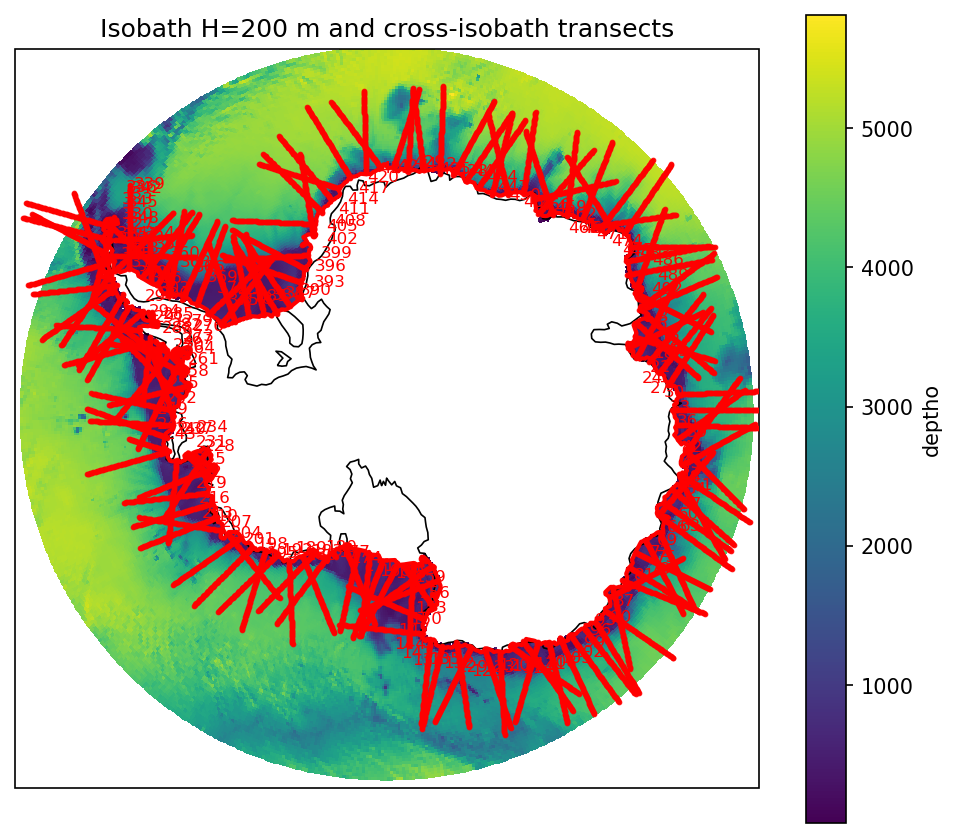

In [246]:
H = 200.0
r_m=np.arange(-0.5 * 100e3, 7.5 * 100e3, 10e3)
# r_m = np.concatenate([r_m, np.array([0.0])])
# r_m = np.unique(r_m)
transects, geom = cross_slope_transects_xesmf(ds.where(ds.volcello > 0.0), var=["thetao", "cfc11", "sigma2_offline", "sf6"], H=H, ds_along=0.5 * 100e3, r = r_m)

fig = plt.figure(figsize=(8, 7))
ax = plt.axes(projection=ccrs.SouthPolarStereo())

pm = plot_isobath_and_transects(
    fig,
    ax,
    ds,
    geom,
    H=H,
    var_bg="deptho",
    nmax=200,
    extent=[-180, 180, -90, -60],
)

fig.colorbar(pm, ax=ax, label="deptho")
plt.show()

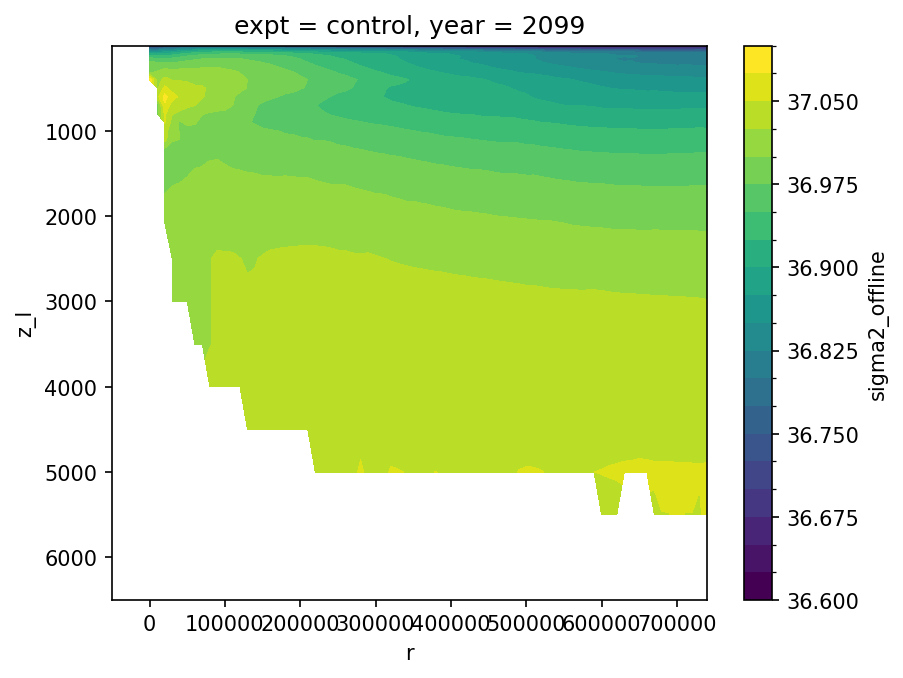

In [247]:
transects.sigma2_offline.isel(year = -1, expt = 0).mean("section").plot.contourf(yincrease = False, levels = 25)

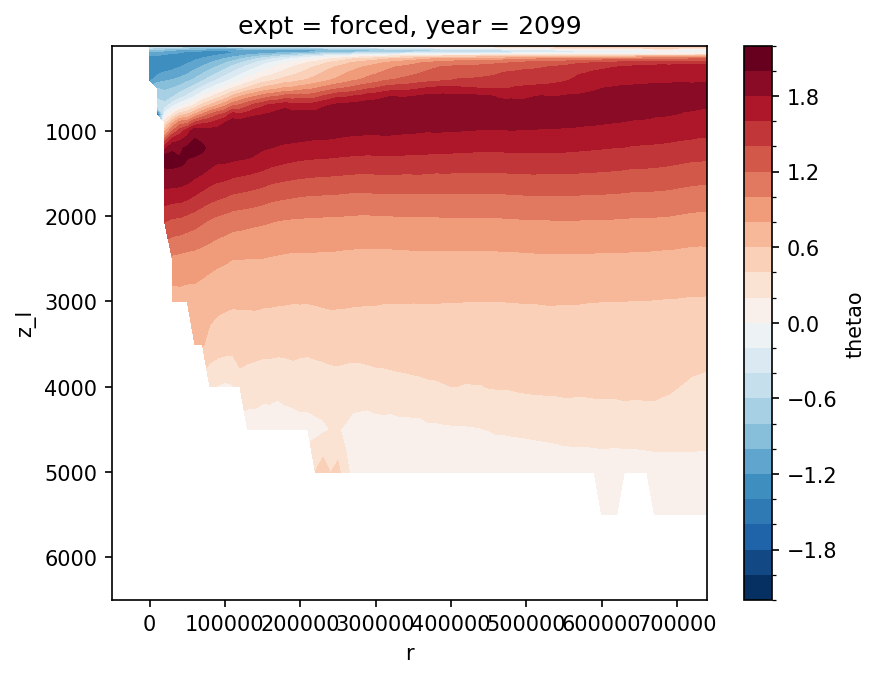

In [248]:
transects.thetao.isel(year = -1, expt = 1).mean("section").plot.contourf(yincrease = False, levels = 25)

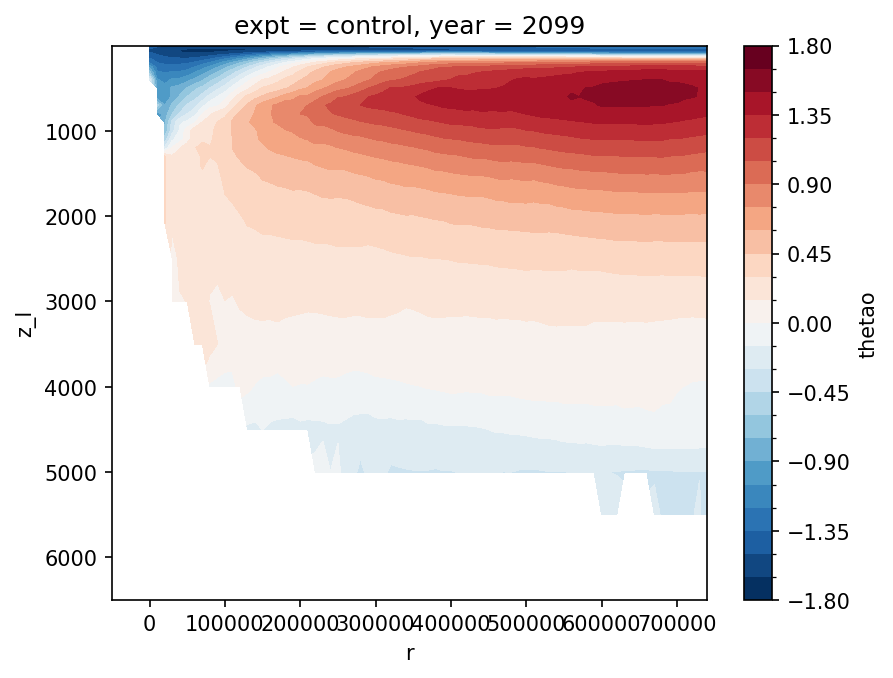

In [249]:
transects.thetao.isel(year = -1, expt = 0).mean("section").plot.contourf(yincrease = False, levels = 25)

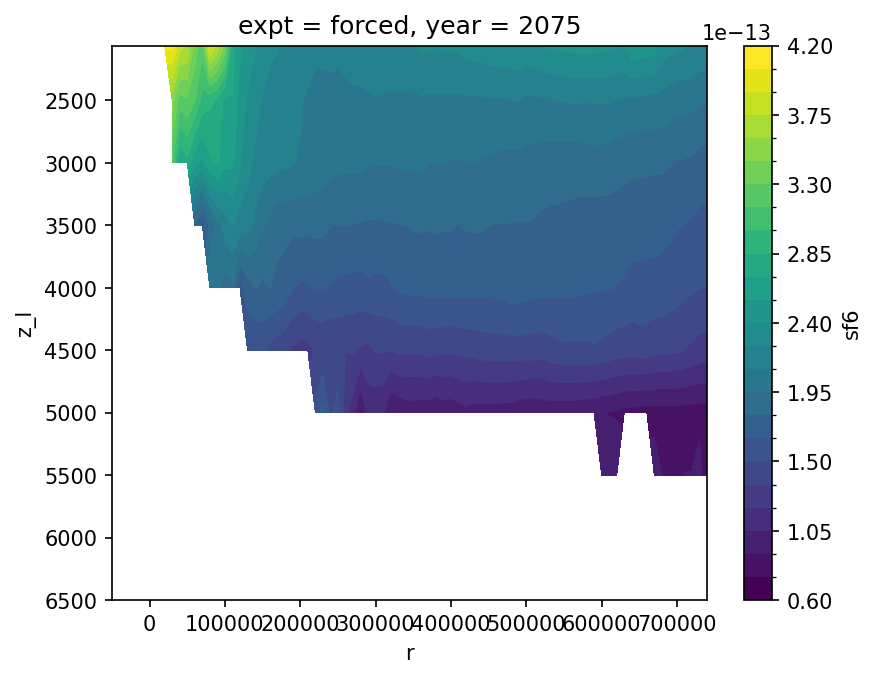

In [250]:
transects.sf6.isel(year = -25, expt = 1).mean("section").sel(z_l = slice(2000, None)).plot.contourf(yincrease = False, levels = 35)

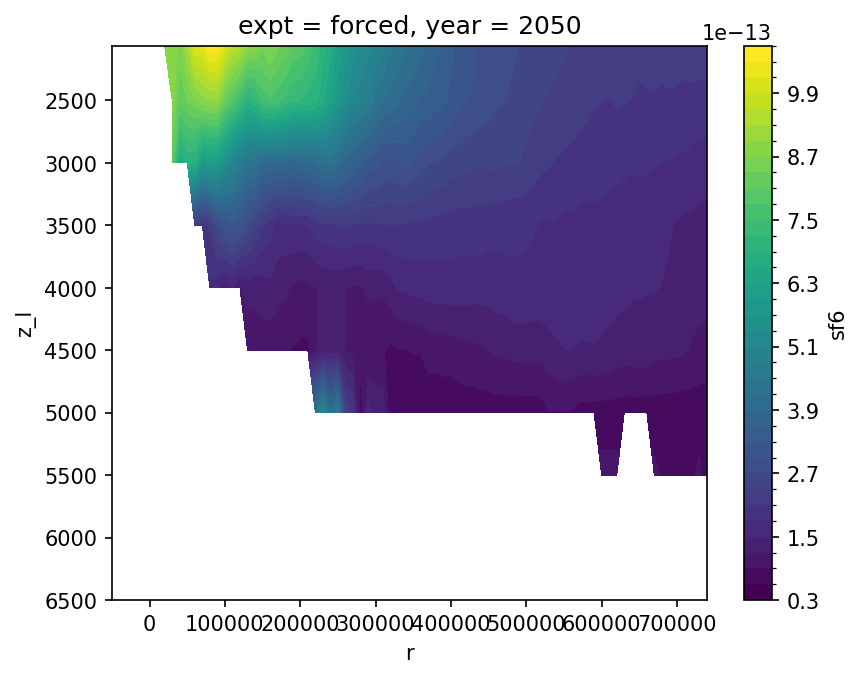

In [251]:
transects.sf6.isel(year = -50, expt = 1).mean("section").sel(z_l = slice(2000, None)).plot.contourf(yincrease = False, levels = 35)

/vortexfs1/home/anthony.meza/miniforge3/envs/cm4x_chapter2/lib/python3.11/site-packages/distributed/client.py:3374: UserWarning: Sending large graph of size 33.11 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


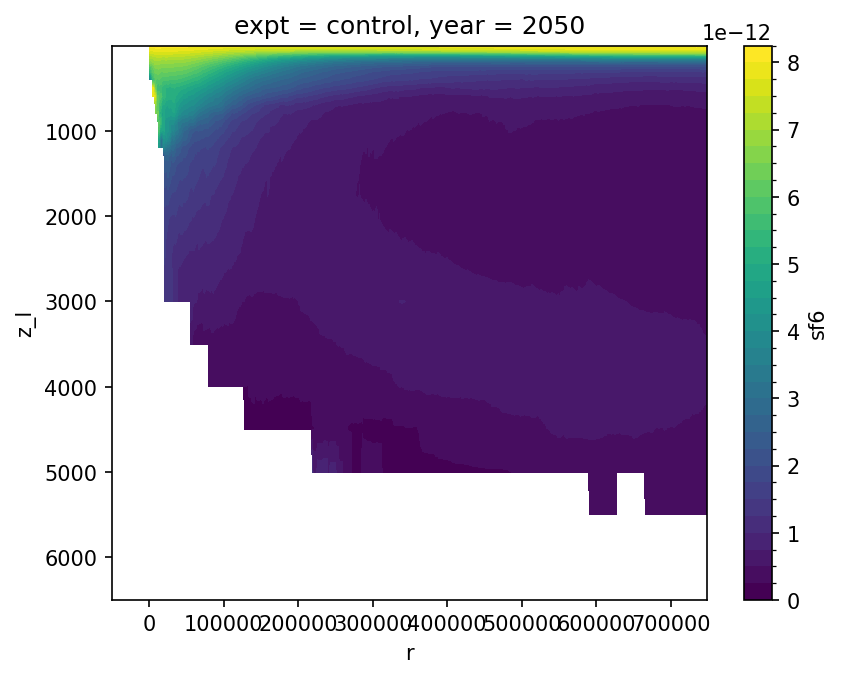

In [221]:
transects.sf6.isel(year = -50, expt = 0).mean("section").plot.contourf(yincrease = False, levels = 35)

/vortexfs1/home/anthony.meza/miniforge3/envs/cm4x_chapter2/lib/python3.11/site-packages/distributed/client.py:3374: UserWarning: Sending large graph of size 65.73 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


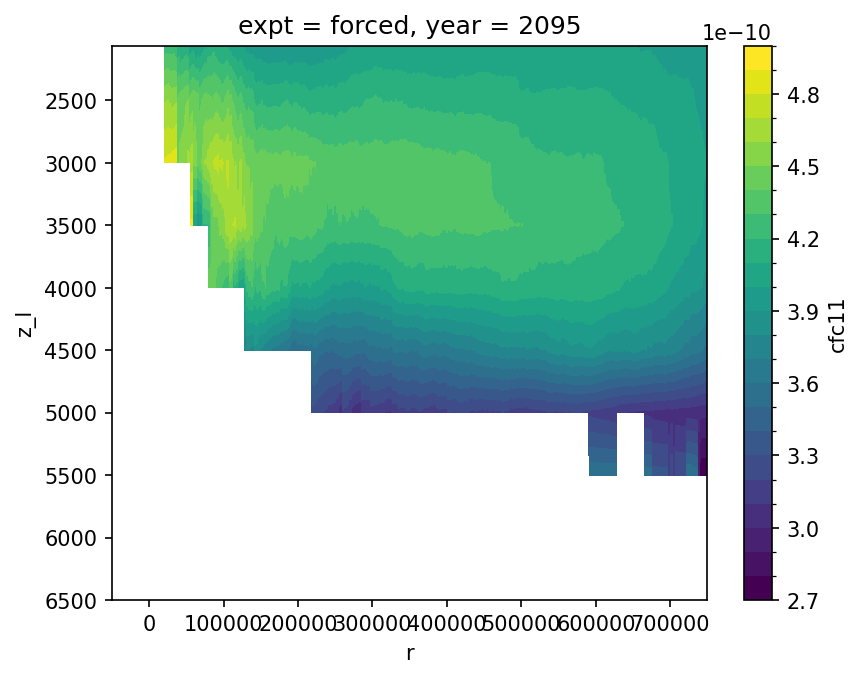

In [242]:
transects.cfc11.isel(year = -5, expt = 1).sel(z_l = slice(2000, None)).mean("section").plot.contourf(yincrease = False, levels = 25)

/vortexfs1/home/anthony.meza/miniforge3/envs/cm4x_chapter2/lib/python3.11/site-packages/distributed/client.py:3374: UserWarning: Sending large graph of size 65.73 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


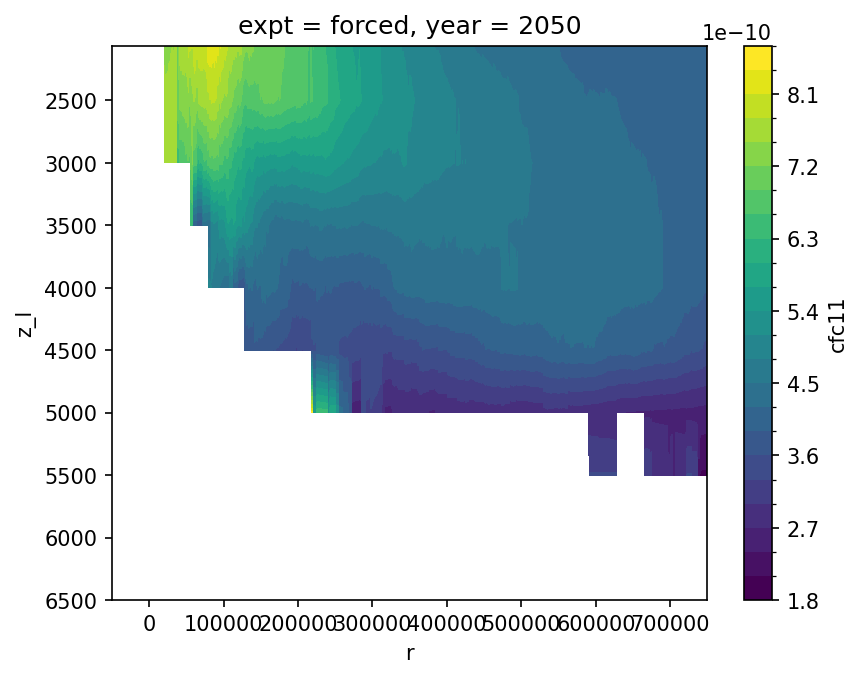

In [237]:
transects.cfc11.isel(year = -50, expt = 1).sel(z_l = slice(2000, None)).mean("section").plot.contourf(yincrease = False, levels = 25)